In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

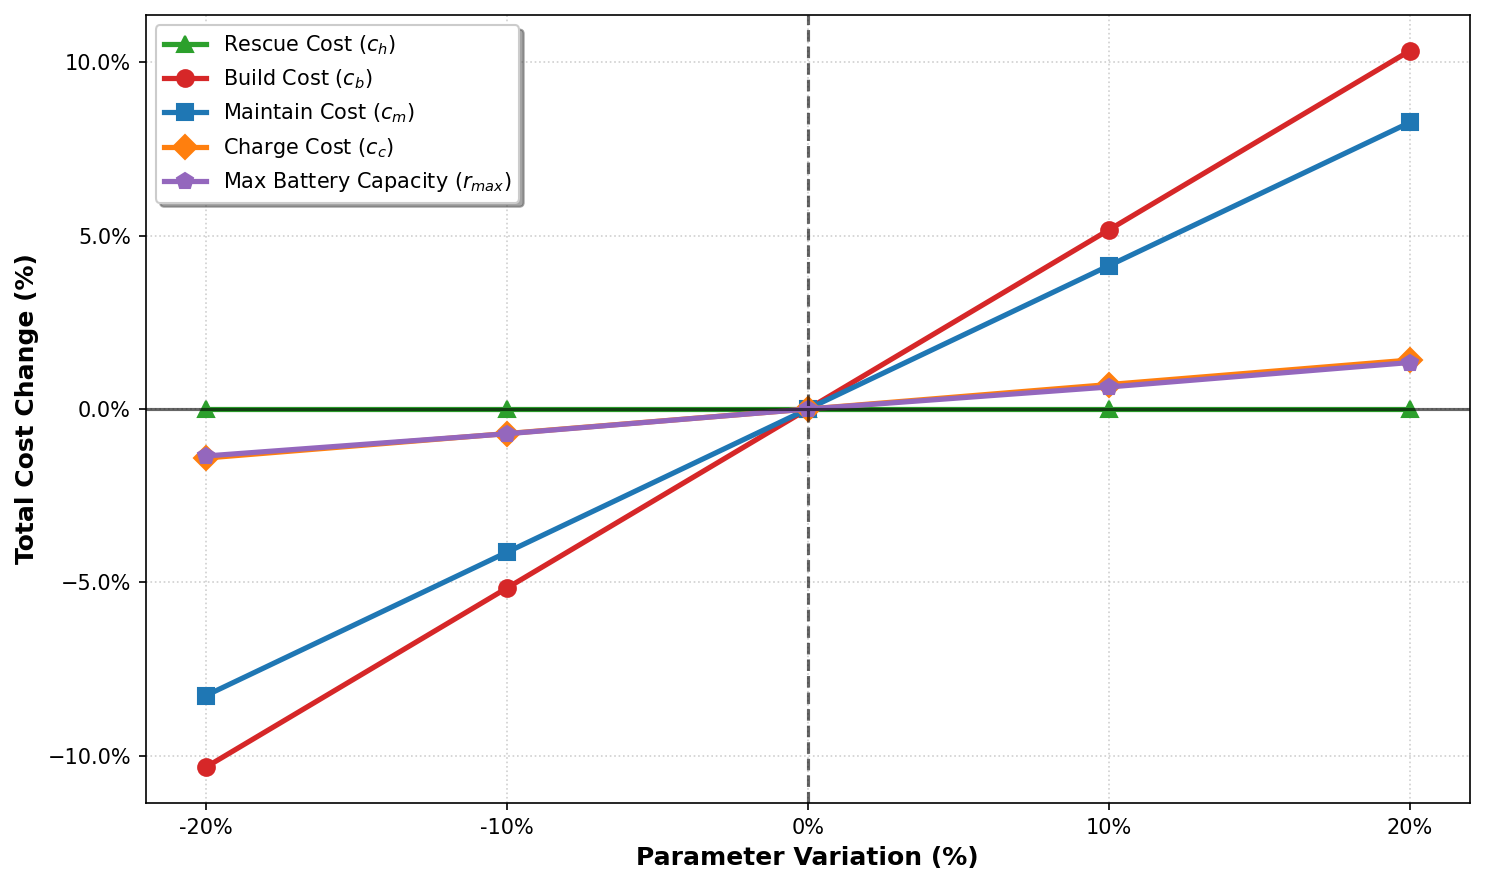

In [9]:
params_config = {
    'Rescue Cost ($c_h$)': '../results/Sensitivity_Analysis/Sensitivity_Data_ch.csv',
    'Build Cost ($c_b$)': '../results/Sensitivity_Analysis/Sensitivity_Data_cb.csv',
    'Maintain Cost ($c_m$)': '../results/Sensitivity_Analysis/Sensitivity_Data_cm.csv',
    'Charge Cost ($c_c$)': '../results/Sensitivity_Analysis/Sensitivity_Data_cc.csv',
    'Max Battery Capacity ($r_{max}$)': '../results/Sensitivity_Analysis/Sensitivity_Data_rmax.csv' # 新增
}

# Set color and style
colors = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e', '#9467bd']
markers = ['^', 'o', 's', 'D', 'p']

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
x_ticks = [-20, -10, 0, 10, 20]

for i, (label, file) in enumerate(params_config.items()):
    try:
        df = pd.read_csv(file)
        costs = df['Total_Cost'].values
        base_cost = costs[2]

        # Calculate the percentage change
        percent_changes = [(c - base_cost) / base_cost * 100 for c in costs]

        # plot
        ax.plot(x_ticks, percent_changes, label=label, color=colors[i],
                marker=markers[i], linewidth=2.5, markersize=8)
    except FileNotFoundError:
        print(f"Warning: File {file} not found. Skipping {label}.")

ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.6)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xlabel('Parameter Variation (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Cost Change (%)', fontsize=12, fontweight='bold')
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{x}%" for x in x_ticks])

# Optimise the display of percentages on the vertical axis
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, linestyle=':', alpha=0.6)

# Add shading and a border to the legend
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10, ncol=1)

fig.tight_layout()

# Saving the figure
plt.savefig("Sensitivity_Comparison.pdf", format='pdf')
plt.show()